In [1]:
# Option A: Simple install
#!pip install requests pandas matplotlib

In [2]:
import requests
import json
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
print("requests version:", requests.__version__)
print("pandas version:", pd.__version__)
print("matplotlib version:", plt.matplotlib.__version__)


requests version: 2.34.2
pandas version: 3.0.3
matplotlib version: 3.11.0


In [3]:
stock = "sh000001"  # Replace with the desired stock code

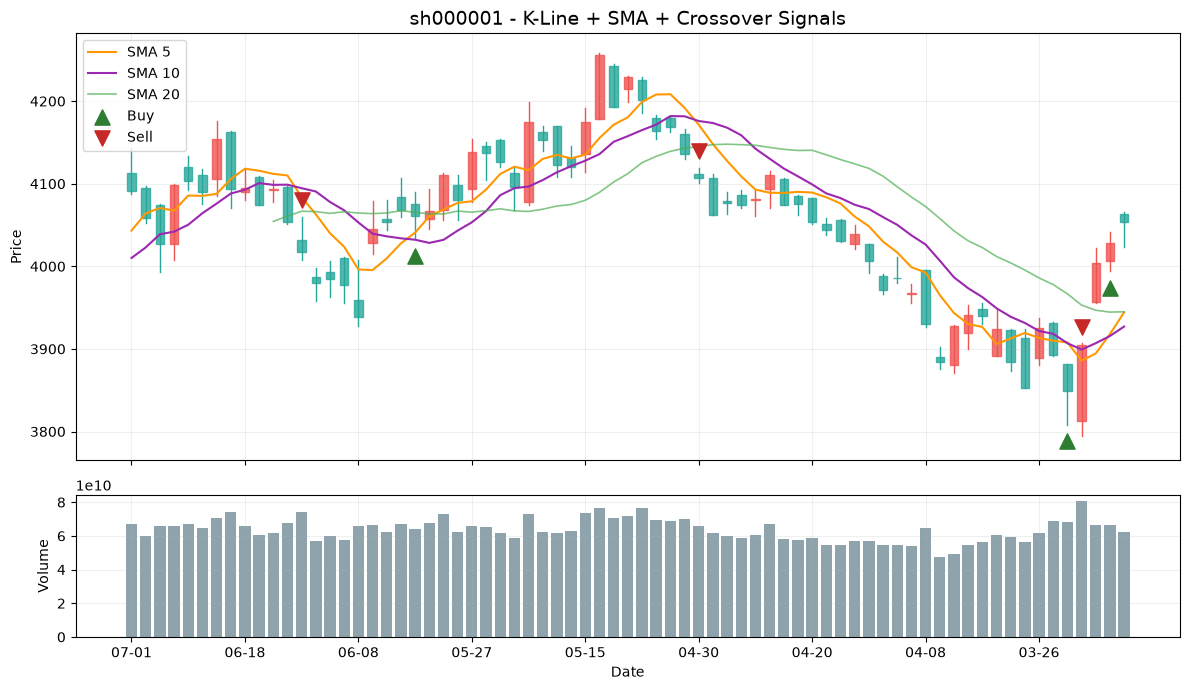


--- Signal Summary ---
🟢 Buy signals:
      date   close   SMA_5  SMA_10
2026-06-02 4075.10 4040.79 4032.22
2026-03-24 3881.28 3907.84 3906.92
2026-03-19 4006.55 3918.00 3915.65

🔴 Sell signals:
      date   close   SMA_5  SMA_10
2026-06-12 4031.51 4083.69 4094.61
2026-04-30 4112.16 4171.48 4175.93
2026-03-23 3813.28 3885.84 3899.23


/tmp/ipykernel_97187/1051698885.py:115: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  print(buy_points[['date', 'close', f'SMA_{fast}', f'SMA_{slow}']].round(2).to_string(index=False))
/tmp/ipykernel_97187/1051698885.py:117: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  print(sell_points[['date', 'close', f'SMA_{fast}', f'SMA_{slow}']].round(2).to_string(index=False))


In [4]:
import requests
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

plt.rcParams["figure.figsize"] = (12, 7)
plt.rcParams["font.sans-serif"] = ["DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False

# ---------------------- Data Fetch ----------------------
def get_stock_data(id, scale, data_len):
    """
    scale: 1=1min,5=5min,15=15min,30=30min,60=1hour,240=1day
    """
    url = 'http://quotes.sina.cn/cn/api/json_v2.php/CN_MarketDataService.getKLineData?symbol={0}&scale={1}&datalen={2}'
    try:
        response = requests.get(url.format(id, scale, data_len), timeout=10)
        response.raise_for_status()
        resp_json = response.json()
        if not resp_json:
            print("API returned empty data")
            return None
        resp_json.reverse()  # oldest → newest

        bar_list = []
        for dc in resp_json:
            bar = {
                'date': pd.to_datetime(dc['day']),
                'open': float(dc['open']),
                'high': float(dc['high']),
                'low': float(dc['low']),
                'close': float(dc['close']),
                'volume': float(dc['volume'])
            }
            bar_list.append(bar)
        return pd.DataFrame(bar_list)
    except Exception as e:
        print(f"Error: {e}")
        return None

# ---------------------- Add Indicators ----------------------
def add_sma(df, periods=[5, 10, 20]):
    df = df.copy()
    for n in periods:
        df[f'SMA_{n}'] = df['close'].rolling(n).mean()
    return df

def add_crossover_signals(df, fast=5, slow=10):
    """Add Buy/Sell signals when fast SMA crosses slow SMA"""
    df = df.copy().dropna(subset=[f'SMA_{fast}', f'SMA_{slow}']).reset_index(drop=True)
    # Current and previous comparison
    df['fast_above_slow'] = df[f'SMA_{fast}'] > df[f'SMA_{slow}']
    df['signal'] = df['fast_above_slow'].astype(int).diff()
    # +1 = Buy (cross above), -1 = Sell (cross below)
    df['buy_signal'] = df['signal'] == 1
    df['sell_signal'] = df['signal'] == -1
    return df

# ---------------------- Plot with Markers ----------------------
def plot_candlestick_with_signals(df, fast=5, slow=10, title=""):
    if df is None or df.empty:
        print("No data to plot")
        return

    df = df.reset_index(drop=True)
    x = range(len(df))
    candle_width = 0.6

    fig, (ax1, ax2) = plt.subplots(2, 1, gridspec_kw={'height_ratios': [3, 1]}, sharex=True)

    # Draw candles
    for i, row in df.iterrows():
        color = '#26a69a' if row['close'] >= row['open'] else '#ef5350'
        body_bottom = min(row['open'], row['close'])
        body_height = abs(row['close'] - row['open'])
        ax1.add_patch(Rectangle((i - candle_width/2, body_bottom), candle_width, body_height, color=color, alpha=0.8))
        ax1.plot([i, i], [row['low'], row['high']], color=color, linewidth=1)

    # Plot SMAs
    ax1.plot(x, df[f'SMA_{fast}'], label=f'SMA {fast}', color='#ff9800', linewidth=1.5)
    ax1.plot(x, df[f'SMA_{slow}'], label=f'SMA {slow}', color='#9c27b0', linewidth=1.5)
    ax1.plot(x, df['SMA_20'], label='SMA 20', color='#4caf50', linewidth=1.2, alpha=0.7)

    # Plot Buy/Sell markers
    buy_points = df[df['buy_signal']]
    sell_points = df[df['sell_signal']]

    ax1.scatter(buy_points.index, buy_points['low'] * 0.995,
                marker='^', color='#2e7d32', s=120, label='Buy', zorder=5)
    ax1.scatter(sell_points.index, sell_points['high'] * 1.005,
                marker='v', color='#c62828', s=120, label='Sell', zorder=5)

    # Format X-axis
    step = max(1, len(x) // 8)
    ax1.set_xticks(x[::step])
    ax1.set_xticklabels(df['date'].dt.strftime('%m-%d')[::step], rotation=30, ha='right')

    ax1.set_title(title, fontsize=14)
    ax1.set_ylabel('Price')
    ax1.legend(loc='upper left')
    ax1.grid(alpha=0.2)

    # Volume
    ax2.bar(x, df['volume'], color='#607d8b', alpha=0.7)
    ax2.set_ylabel('Volume')
    ax2.set_xlabel('Date')
    ax2.grid(alpha=0.2)

    plt.tight_layout()
    plt.show()

    # Print signal summary
    print("\n--- Signal Summary ---")
    print("🟢 Buy signals:")
    print(buy_points[['date', 'close', f'SMA_{fast}', f'SMA_{slow}']].round(2).to_string(index=False))
    print("\n🔴 Sell signals:")
    print(sell_points[['date', 'close', f'SMA_{fast}', f'SMA_{slow}']].round(2).to_string(index=False))


# ---------------------- Run Everything ----------------------
df = get_stock_data(f'{stock}', scale=240, data_len=80)  # 80 days of daily data
if df is not None and not df.empty:
    df = add_sma(df, periods=[5, 10, 20])
    df = add_crossover_signals(df, fast=5, slow=10)  # Use SMA5 vs SMA10
    plot_candlestick_with_signals(df, fast=5, slow=10, title="sh000001 - K-Line + SMA + Crossover Signals")
else:
    print("❌ Failed to load data")